# 02 — ETL & Data Cleaning
Validating the cleaning logic before porting to `etl/transform.py`.

## 1. Imports

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")
%matplotlib inline


## 2. Extract

In [24]:
RAW = Path("../data/raw/Online_Retail.csv")
df_raw = pd.read_csv(RAW,encoding='latin1')
print(f"Raw shape: {df_raw.shape}")


Raw shape: (541909, 8)


## 3. Transform — step by step

### 3a. Parse dates

In [25]:
df = df_raw.copy()
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
print(df["InvoiceDate"].dtype)

datetime64[ns]


### 3b. Drop missing CustomerID

In [26]:
before = len(df)
df = df.dropna(subset=["CustomerID"])
df["CustomerID"] = df["CustomerID"].astype(int).astype(str)
print(f"Dropped {before - len(df):,} rows with null CustomerID")
print(f"Remaining: {len(df):,}")

Dropped 135,080 rows with null CustomerID
Remaining: 406,829


### 3c. Remove cancellations

In [27]:
before = len(df)
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]
print(f"Dropped {before - len(df):,} cancellation rows")

Dropped 8,905 cancellation rows


### 3d. Remove non-positive quantity / price

In [28]:
before = len(df)
df = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)]
print(f"Dropped {before - len(df):,} rows with zero/negative Quantity or UnitPrice")


Dropped 40 rows with zero/negative Quantity or UnitPrice


### 3e. Remove duplicates

In [29]:
before = len(df)
df = df.drop_duplicates()
print(f"Dropped {before - len(df):,} duplicate rows")


Dropped 5,192 duplicate rows


### 3f. Remove outliers (99th percentile cap)

In [30]:
q99_qty   = df["Quantity"].quantile(0.99)
q99_price = df["UnitPrice"].quantile(0.99)

before = len(df)
df = df[(df["Quantity"] <= q99_qty) & (df["UnitPrice"] <= q99_price)]
print(f"Outlier cap : Qty ≤ {q99_qty:.0f}, Price ≤ £{q99_price:.2f}")
print(f"Dropped {before - len(df):,} outlier rows")


Outlier cap : Qty ≤ 120, Price ≤ £14.95
Dropped 7,611 outlier rows


### 3g. Standardise column names

In [31]:
df["Revenue"] = df["Quantity"] * df["UnitPrice"]
df.head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


## 4. Cleaned dataset summary

In [32]:
print(f"Final shape : {df.shape}")
print(f"Date range  : {df['InvoiceDate'].min().date()} → {df['InvoiceDate'].max().date()}")
print(f"Customers   : {df['CustomerID'].nunique():,}")
print(f"Orders      : {df['InvoiceNo'].nunique():,}")
print(f"Total revenue: £{df['Revenue'].sum():,.2f}")
df.info()

Final shape : (385081, 9)
Date range  : 2010-12-01 → 2011-12-09
Customers   : 4,290
Orders      : 17,980
Total revenue: £6,896,447.28
<class 'pandas.core.frame.DataFrame'>
Index: 385081 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    385081 non-null  object        
 1   StockCode    385081 non-null  object        
 2   Description  385081 non-null  object        
 3   Quantity     385081 non-null  int64         
 4   InvoiceDate  385081 non-null  datetime64[ns]
 5   UnitPrice    385081 non-null  float64       
 6   CustomerID   385081 non-null  object        
 7   Country      385081 non-null  object        
 8   Revenue      385081 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(5)
memory usage: 29.4+ MB


## 5. Validate — no nulls remain

In [33]:
assert df.isnull().sum().sum() == 0, "Nulls still present!"
assert (df["Quantity"] > 0).all(), "Non-positive quantities!"
assert (df["UnitPrice"] > 0).all(), "Non-positive prices!"
print("All assertions passed ✓")

All assertions passed ✓


## 6. Converting the data type to string

In [34]:
object_cols = ["InvoiceNo", "StockCode", "Description", "Country"]

for col in object_cols:
    df[col] = df[col].astype(str)

## 7. Save interim (local Parquet for notebook use)

In [ ]:
Path("../data/interim").mkdir(parents=True, exist_ok=True)
df.to_parquet("../data/interim/cleaned.parquet", index=False)
print("Saved → data/interim/cleaned.parquet")

## 8. Revenue distribution after cleaning

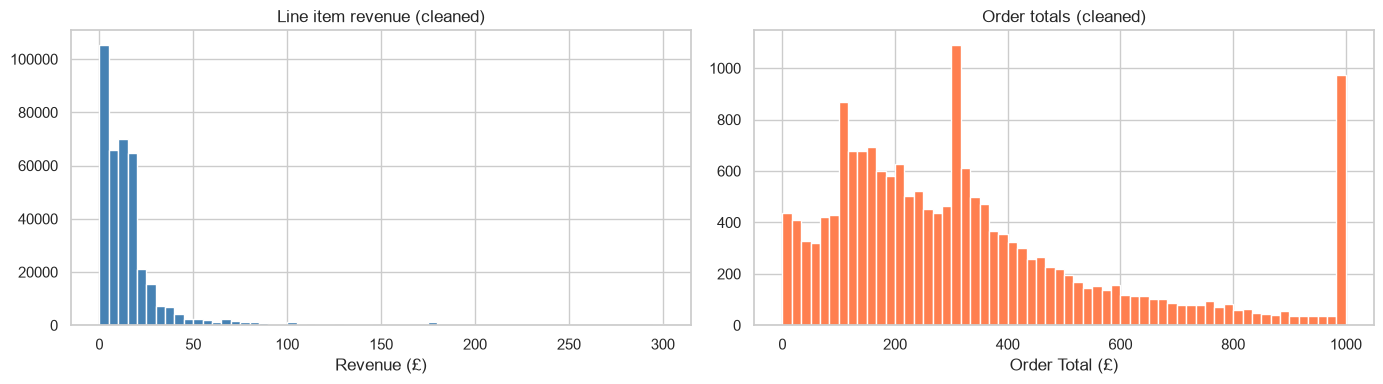

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df["Revenue"].clip(0, 300).hist(bins=60, ax=axes[0], color="steelblue", edgecolor="white")
axes[0].set_title("Line item revenue (cleaned)")
axes[0].set_xlabel("Revenue (£)")

order_totals = df.groupby("InvoiceNo")["Revenue"].sum()
order_totals.clip(0, 1000).hist(bins=60, ax=axes[1], color="coral", edgecolor="white")
axes[1].set_title("Order totals (cleaned)")
axes[1].set_xlabel("Order Total (£)")

plt.tight_layout()
plt.show()

## Summary

* Merged all raw data into a single dataset.
* Converted dates and standardized data types.
* Removed missing Customer IDs, cancellations, and invalid transactions.
* Eliminated duplicate records.
* Filtered extreme outliers using the 99th percentile cap.
* Created a Revenue feature (Quantity × UnitPrice).
* Validated data quality and saved the cleaned dataset as Parquet.

Result: A clean, consistent dataset ready for feature engineering, customer segmentation, and retention analysis.